# ML Pipeline — ETL-sourced Training Data

End-to-end training pipeline that loads fully prepared features directly from the **SQLite database** maintained by `etl.py`, instead of re-fetching and re-engineering raw data on every run.

Four models are trained and saved:

| Model | Objective | Purpose | Saved as |
|---|---|---|---|
| LightGBM | MAE (default) | Best-estimate forecast | `best_lgbm_model_bayesian_etl.pkl` |
| LightGBM conservative | Quantile α=0.95 | Minimise under-prediction risk | `best_lgbm_model_bayesian_conservative_etl.pkl` |
| XGBoost | squared-error | Best-estimate forecast | `best_xgb_model_bayesian_etl.pkl` |
| XGBoost conservative | Quantile α=0.95 | Minimise under-prediction risk | `best_xgb_model_bayesian_conservative_etl.pkl` |

Hyperparameters are tuned with `BayesSearchCV` using time-series-aware 5-fold cross-validation (`TimeSeriesSplit`). The reported holdout scores are calculated separately with the leakage-safe 48-hour walk-forward simulation; CV scores are used only for parameter selection.

In [10]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
sys.path.insert(0, os.path.abspath('../src'))

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import pandas as pd

from train_model_predict import (plot_learning_curve, print_scores,
                                 save_model_to_pickle, train_test_split_by_date,
                                 tune_model_bayesian)
from walk_forward import predict_date_range_in_memory

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Update & Load Data from Database

`update_database()` is idempotent:
- **First run** — seeds both tables from the Kaggle CSV and the Open-Meteo API.
- **Subsequent runs** — only fills the gap between the last stored timestamp and yesterday; usually completes in seconds.

After the update, `load_combined_data()` reads the pre-joined `energy_weather_combined` view — all engineered features are already stored in the DB, so no re-computation is needed here.

Two columns are dropped before training because they are informational, not predictive:
- `smard_forecast_mwh` — SMARD official forecast, kept in the DB for actual-vs-forecast comparison
- `data_source` — provenance label (`'kaggle'` / `'smard'`)

The target column `energy_demand_mwh` is renamed to `EnergyDemand` to match the existing pipeline conventions used throughout the other notebooks.

In [11]:
from etl import update_database, get_connection, load_combined_data

# Ensure the database is up to date — no-op if already current
update_database()

# Load the pre-joined, feature-engineered dataset from the DB view
conn = get_connection()
df_raw = load_combined_data(conn)
conn.close()

# Drop non-predictive columns; rename target to match existing pipeline conventions
df_for_modeling = (
    df_raw
    .drop(columns=['smard_forecast_mwh', 'data_source'], errors='ignore')
    .rename(columns={'energy_demand_mwh': 'EnergyDemand'})
    .dropna()
    .reset_index(drop=True)
)

print(f"Dataset : {len(df_for_modeling):,} rows")
print(f"Range   : {df_for_modeling['time'].min().date()} – {df_for_modeling['time'].max().date()}")
print(f"Features: {df_for_modeling.shape[1] - 1}  |  Target: EnergyDemand")
display(df_for_modeling.head(3))

Database ready: c:\Projects\DataScience\Portfolio\energy_demand_forecast\workspace_energy_demand\db\energy_demand.db

Current data status:
  energy         :  65848 rows | max: 2026-07-13T23:00:00+0200 | up-to-date: True
  weather        :  66001 rows | max: 2026-07-14T01:00:00+0200 | up-to-date: True

[Energy] Up to date — nothing to do.

[Weather] Up to date — nothing to do.

Done.
  energy_demand : 65848 rows | max: 2026-07-13T23:00:00+0200
  weather       : 66001 rows | max: 2026-07-14T01:00:00+0200
Dataset : 65,848 rows
Range   : 2019-01-08 – 2026-07-13
Features: 29  |  Target: EnergyDemand


,time,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,is_school_holiday,...,rain,snowfall,wind_speed_10m,shortwave_radiation,apparent_temperature_lag_24h,apparent_temperature_rolling_mean_24h,shortwave_radiation_0m_lag_24h,shortwave_radiation_0m_rolling_mean_24h,heating_degree,cooling_degree
0,2019-01-08 01:00:00+01:00,52754.4700,2019,1,1,1,0,0,0.0,0,...,0.497775,0.000000,23.098559,0.0,-1.026161,0.200133,0.0,10.766481,17.925307,0.0
1,2019-01-08 02:00:00+01:00,51889.2625,2019,2,1,1,0,0,0.0,0,...,0.518651,0.023420,25.225514,0.0,-0.669110,0.246002,0.0,10.766481,18.115502,0.0
2,2019-01-08 03:00:00+01:00,52475.5475,2019,3,1,1,0,0,0.0,0,...,0.561141,0.046841,25.289731,0.0,-0.652509,0.269069,0.0,10.766481,18.155768,0.0


In [12]:
df_for_modeling.columns

Index(['time', 'EnergyDemand', 'year', 'hour', 'weekday', 'month',
       'is_weekend', 'is_holiday', 'holiday_ratio', 'is_school_holiday',
       'school_holiday_ratio', 'is_workday', 'is_bridge_day', 'holiday_weight',
       'is_pandemic_time', 'energy_demand_lag_24h', 'energy_demand_lag_168h',
       'energy_demand_rolling_mean_24h', 'energy_demand_rolling_mean_168h',
       'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m',
       'shortwave_radiation', 'apparent_temperature_lag_24h',
       'apparent_temperature_rolling_mean_24h',
       'shortwave_radiation_0m_lag_24h',
       'shortwave_radiation_0m_rolling_mean_24h', 'heating_degree',
       'cooling_degree'],
      dtype='str')

## 2. Train / Test Split

A **chronological split at 2025-10-01** is used for all four models:
- **Train** — 2019-01-08 to 2025-09-30
- **Test** — 2025-10-01 onwards (unseen future data)

The holdout is evaluated with the project's **48-hour walk-forward simulation**. For every target day D, actual demand is visible only through D-2; D-1 is predicted recursively before D. This prevents true test-period demand from leaking through lag and rolling features. Historical weather remains actual weather, matching evaluation mode `walk_forward_48h_actual_weather`.

The split date is passed as a tz-aware `pd.Timestamp` because the `time` column retains `Europe/Berlin` timezone information from the database.

In [13]:
SPLIT_DATE = pd.Timestamp('2025-10-01', tz='Europe/Berlin')

features_train, target_train, features_test, target_test = train_test_split_by_date(
    df_for_modeling,
    date_column='time',
    target_column='EnergyDemand',
    split_date=SPLIT_DATE,
)

print(f"Train : {len(features_train):,} rows  ({features_train.shape[1]} features)")
print(f"Test  : {len(features_test):,} rows")

TEST_START = SPLIT_DATE.strftime('%Y-%m-%d')
TEST_END = df_for_modeling['time'].max().strftime('%Y-%m-%d')
walk_forward_source = df_raw.loc[
    df_raw['time'] <= df_for_modeling['time'].max()
].copy()

def evaluate_walk_forward(model, model_name):
    result = predict_date_range_in_memory(
        model=model,
        combined_data=walk_forward_source,
        start_date=TEST_START,
        end_date=TEST_END,
        model_name=model_name,
    )
    print_scores(model_name, result['actual_mwh'], result['prediction_mwh'])
    return result

print(f"Walk-forward evaluation: {TEST_START} to {TEST_END}")

Train : 58,984 rows  (28 features)
Test  : 6,864 rows
Walk-forward evaluation: 2025-10-01 to 2026-07-13


## 3. LightGBM — Standard (Best-Estimate)

LightGBM is tuned with `BayesSearchCV` over a continuous hyperparameter space using `TimeSeriesSplit(n_splits=5)`. The default `objective='regression'` minimises MAE, producing an unbiased best-estimate forecast. Tree-based models do not require feature scaling, so no preprocessor pipeline is needed.

| Parameter | Search range |
|---|---|
| `n_estimators` | 50 – 500 |
| `learning_rate` | 0.01 – 0.30 |
| `max_depth` | 3 – 15 |

In [14]:
!uv add scikit-optimize

from skopt import BayesSearchCV

Resolved 121 packages in 2ms
Checked 111 packages in 18ms


In [ ]:
from lightgbm import LGBMRegressor

param_lgbm = {
    'n_estimators':  (50, 500),
    'learning_rate': (0.01, 0.3),
    'max_depth':     (3, 15),
}

model_lgbm = LGBMRegressor(random_state=42, force_col_wise=True)
best_model_lgbm, best_params_lgbm = tune_model_bayesian(
    model_pipeline=model_lgbm,
    in_param_bayes=param_lgbm,
    in_features_train=features_train,
    in_target_train=target_train,
)
print(f"Best hyperparameters: {best_params_lgbm}")
print()

eval_lgbm = evaluate_walk_forward(best_model_lgbm, 'LightGBM')

save_model_to_pickle(best_model_lgbm, '../models/best_lgbm_model_bayesian_etl.pkl')
print("Saved → ../models/best_lgbm_model_bayesian_etl.pkl")

[LightGBM] [Info] Total Bins 3990
[LightGBM] [Info] Number of data points in the train set: 58984, number of used features: 28
[LightGBM] [Info] Start training from score 54659.794154
Best hyperparameters: OrderedDict({'learning_rate': 0.1254157079912377, 'max_depth': 15, 'n_estimators': 500})

-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM            1470.21    1864.09     0.96
Saved → ../models/best_lgbm_model_bayesian_etl.pkl


## 4. XGBoost — Standard (Best-Estimate)

XGBoost is tuned with the same Bayesian optimisation approach. The search space is extended with subsampling and column-sampling parameters that help control overfitting on the large training set.

| Parameter | Search range |
|---|---|
| `n_estimators` | 50 – 500 |
| `max_depth` | 3 – 15 |
| `learning_rate` | 0.01 – 0.30 |
| `subsample` | 0.5 – 1.0 |
| `colsample_bytree` | 0.5 – 1.0 |

In [16]:
from xgboost import XGBRegressor

param_xgb = {
    'n_estimators':     (50, 500),
    'max_depth':        (3, 15),
    'learning_rate':    (0.01, 0.3),
    'subsample':        (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
}

model_xgb = XGBRegressor(random_state=42)
best_model_xgb, best_params_xgb = tune_model_bayesian(
    model_pipeline=model_xgb,
    in_param_bayes=param_xgb,
    in_features_train=features_train,
    in_target_train=target_train,
)
print(f"Best hyperparameters: {best_params_xgb}")
print()

eval_xgb = evaluate_walk_forward(best_model_xgb, 'XGBoost')

save_model_to_pickle(best_model_xgb, '../models/best_xgb_model_bayesian_etl.pkl')
print("Saved → ../models/best_xgb_model_bayesian_etl.pkl")

Best hyperparameters: OrderedDict({'colsample_bytree': 0.7370121100709317, 'learning_rate': 0.06601850792540921, 'max_depth': 9, 'n_estimators': 407, 'subsample': 0.6429141732762403})

-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost             1449.58    1840.44     0.96
Saved → ../models/best_xgb_model_bayesian_etl.pkl


## 5. Learning Curves

Learning curves compare training MAE vs. cross-validation MAE as the training set size grows. They help diagnose:
- **Overfitting** — large persistent gap between train and CV score
- **Underfitting** — both scores converge at a high MAE
- **Good fit** — the gap closes as training data increases

The conservative models are expected to show higher absolute MAE than their standard counterparts, because quantile loss at α=0.95 penalises under-predictions much more heavily than over-predictions, yielding a systematically biased but intentionally conservative estimator.

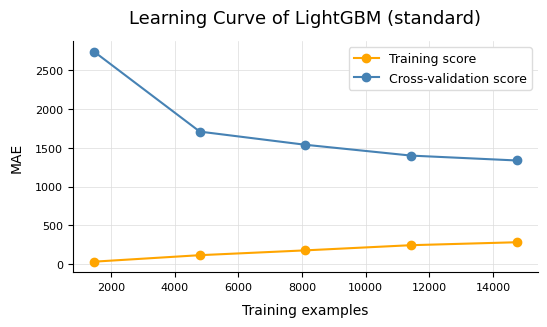

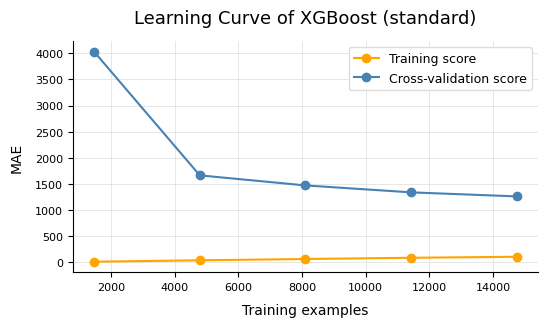

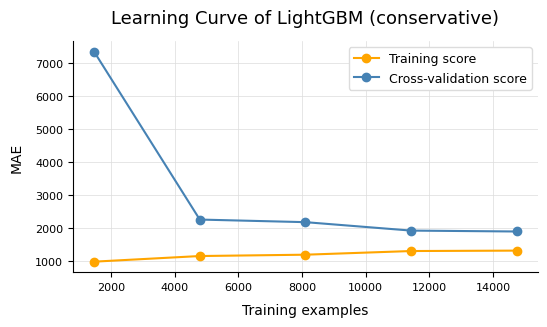

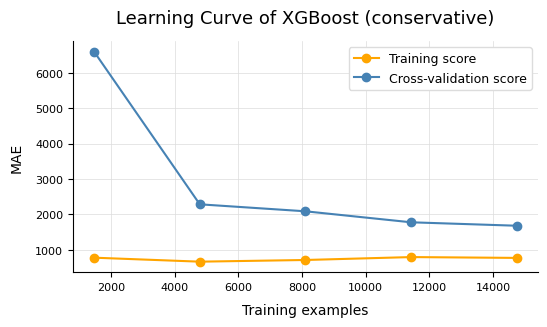

In [ ]:
plot_learning_curve(best_model_lgbm, 'LightGBM (standard)', features_train, target_train)
plot_learning_curve(best_model_xgb, 'XGBoost (standard)',  features_train, target_train)